In [1]:
# --- STEP 0: Install deps (if not already) ---
import pandas as pd
import numpy as np
from scipy.signal import resample
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.fft import fft
import requests

In [2]:
# --- STEP 1: Load the cleaned dataset ---

total_dataset_df = pd.read_csv("total_dataset.csv")
display(total_dataset_df.head())
total_dataset_df.info()

,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,ir_0,ir_1,...,ir_190,ir_191,ir_192,ir_193,ir_194,ir_195,ir_196,ir_197,ir_198,ir_199
0,107.0,44,1,180.0,98,30.246914,122,83,53465.0,53481.287901,...,51742.595769,51551.915175,51688.538092,51668.543078,51680.648565,51598.149933,51214.295208,52088.077148,51488.322949,51220.006983
1,125.0,30,0,154.0,43,18.131219,102,68,54755.0,54768.967582,...,54816.839729,54710.925697,54838.750020,54832.248470,54814.892490,54867.144060,54831.912227,55002.472530,54864.731521,54643.093888
2,93.0,61,0,144.0,62,29.899691,141,93,61920.0,61786.696546,...,60978.225894,60852.715298,61003.809215,61051.422986,61050.821855,60940.116256,60835.006409,61174.300720,60879.766867,61023.488015
3,71.0,45,1,172.0,103,34.816117,139,96,59870.0,59800.345442,...,60550.888203,60629.806369,60580.859679,60527.160764,60580.727359,60585.783915,60630.894420,60610.373552,60683.493785,60457.164533
4,166.0,23,1,172.0,88,29.745809,112,75,61487.0,61629.954266,...,60426.990175,60437.996852,60472.943335,60318.838228,60400.617660,60480.502501,60410.353242,60524.827164,60259.382240,60521.376045


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Columns: 208 entries, heartRate to ir_199
dtypes: float64(203), int64(5)
memory usage: 871.1 KB


In [3]:
# --- Step 1: Extract the relevant columns for IR and RED signals ---
ir_cols = [c for c in total_dataset_df.columns if c.startswith("ir_")]

In [4]:
# --- Function to extract time-domain and frequency-domain features from a signal ---
def extract_features(signal):
    # Ensure the signal is a float numpy array
    signal = np.asarray(signal, dtype=float)

    # Handle cases with all NaN values after conversion
    if np.all(np.isnan(signal)):
        # Return a list of NaNs for all features if the signal is all NaNs
        return [np.nan] * 14 # 14 is the number of features being extracted

    # Time-domain features
    mean_signal = np.nanmean(signal) # Use nanmean to ignore NaNs
    median_signal = np.nanmedian(signal) # Use nanmedian to ignore NaNs
    std_signal = np.nanstd(signal) # Use nanstd to ignore NaNs
    min_signal = np.nanmin(signal) if not np.all(np.isnan(signal)) else np.nan # Handle min/max on all NaNs
    max_signal = np.nanmax(signal) if not np.all(np.isnan(signal)) else np.nan # Handle min/max on all NaNs
    range_signal = max_signal - min_signal if not np.all(np.isnan(signal)) else np.nan # Handle range on all NaNs

    # SciPy stats functions handle NaNs with nan_policy='omit' or 'propagate'
    # Let's ensure we handle potential NaNs explicitly or rely on default nan_policy
    skewness_signal = skew(signal, nan_policy='omit') if len(signal[~np.isnan(signal)]) > 1 else np.nan # Need at least 2 non-NaN for skew
    kurtosis_signal = kurtosis(signal, nan_policy='omit') if len(signal[~np.isnan(signal)]) > 3 else np.nan # Need at least 4 non-NaN for kurtosis


    # Peak features (find peaks in the signal) - find_peaks requires non-NaN input
    non_nan_signal = signal[~np.isnan(signal)]
    peaks, _ = find_peaks(non_nan_signal)
    num_peaks = len(peaks)
    mean_peak_amplitude = np.nanmean(non_nan_signal[peaks]) if num_peaks > 0 else np.nan # Use nanmean

    # Frequency-domain features using FFT - fft requires non-NaN input
    if len(non_nan_signal) == 0:
         return [np.nan] * 14 # Return NaNs if no non-NaN data for FFT

    fft_values = fft(non_nan_signal)
    fft_freq = np.fft.fftfreq(len(non_nan_signal))
    fft_magnitude = np.abs(fft_values)

    # Extract dominant frequency (proxy for heart rate)
    # Need to handle case where all magnitudes are zero (e.g., constant signal)
    if np.all(fft_magnitude[1:] == 0):
         dominant_freq = np.nan
    else:
        dominant_freq = np.abs(fft_freq[np.argmax(fft_magnitude[1:]) + 1])  # Skip zero frequency (DC component)


    # Total spectral energy
    total_energy = np.sum(fft_magnitude**2)



    return [
        mean_signal, median_signal, std_signal, min_signal, max_signal, range_signal,
        skewness_signal, kurtosis_signal, num_peaks, mean_peak_amplitude,
        dominant_freq, total_energy
    ]

In [13]:
# --- Extract features for both IR and Red signals ---
def extract_features_from_df(df_clean, ir_columns):
    features = []
    for i, row in df_clean.iterrows():
        # Extract IR and Red signal features
        ir_signal = row[ir_columns].values

        ir_features = extract_features(ir_signal)

        # Combine IR and Red features into one set
        combined_features = ir_features

        # Append demographics
        demographics = [
            row['userAge'], row['userGender'], row['userHeight'], row['userWeight'],
            row['userBmi'], row['heartRate'] , row['systolic_BP'], row['diastolic_BP'] # Assuming these columns are present
        ]

        features.append(combined_features + demographics)

    return np.array(features)


In [14]:
# --- Prepare feature matrix and labels ---
X = extract_features_from_df(total_dataset_df, ir_cols)


In [15]:
# --- Create a DataFrame for the features ---
columns = [
    'mean', 'median', 'std', 'min', 'max', 'range', 'skewness', 'kurtosis', 'num_peaks', 'mean_peak_amplitude', 'dominant_freq',
     'total_energy', 'userAge', 'userGender', 'userHeight', 'userWeight', 'heartRate', 'userBmi', 'systolic_BP', 'diastolic_BP' 
]

In [16]:
X_df = pd.DataFrame(X, columns=columns)

In [ ]:
# --- Labels (systolic_BP, diastolic_BP) ---
y = total_dataset_df[['systolic_BP', 'diastolic_BP']].values

In [17]:
display(X_df.head())

,mean,median,std,min,max,range,skewness,kurtosis,num_peaks,mean_peak_amplitude,dominant_freq,total_energy,userAge,userGender,userHeight,userWeight,heartRate,userBmi,systolic_BP,diastolic_BP
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,0.005,1.105852e+14,44.0,1.0,180.0,98.0,30.246914,107.0,122.0,83.0
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,0.005,1.209246e+14,30.0,0.0,154.0,43.0,18.131219,125.0,102.0,68.0
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,0.005,1.500571e+14,61.0,0.0,144.0,62.0,29.899691,93.0,141.0,93.0
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,0.005,1.454741e+14,45.0,1.0,172.0,103.0,34.816117,71.0,139.0,96.0
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,0.005,1.471847e+14,23.0,1.0,172.0,88.0,29.745809,166.0,112.0,75.0


In [18]:
# Save combined_df to a CSV file for download
X_df.to_csv("total_dataset_features2.csv", index=False)

In [4]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

# Load your CSV file
df = pd.read_csv("bp_dataset_resampledV2.csv")

# Extract IR columns
ir_columns = [col for col in df.columns if col.startswith('ir_')]
ir_data = df[ir_columns].to_numpy()

# Sampling settings
fs_original = 6.667  # Hz
fs_target = 50     # Hz (adjust to 100 if needed)
n_samples = ir_data.shape[1]
duration = n_samples / fs_original
t_original = np.arange(n_samples) / fs_original
t_upsampled = np.linspace(0, duration, int(duration * fs_target))

# Cubic spline interpolation row-wise
def upsample_row(row):
    spline = CubicSpline(t_original, row)
    return spline(t_upsampled)

ir_upsampled_data = np.apply_along_axis(upsample_row, axis=1, arr=ir_data)
new_ir_columns = [f'ir_{i}' for i in range(ir_upsampled_data.shape[1])]
ir_upsampled_df = pd.DataFrame(ir_upsampled_data, columns=new_ir_columns)

# Clean up: remove old IR and RED columns
df_cleaned = df.drop(columns=[col for col in df.columns if col.startswith('ir_') or col.startswith('red_')])

# Merge cleaned data with upsampled IR
df_final = pd.concat([df_cleaned.reset_index(drop=True), ir_upsampled_df], axis=1)

# Save output
df_final.to_csv("bp_dataset_upsampled_50Hz.csv", index=False)
print("Upsampled dataset saved as: bp_dataset_upsampled_50Hz.csv")


Upsampled dataset saved as: bp_dataset_upsampled_50Hz.csv


In [5]:
display(df_final.head())

,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,ir_0,...,ir_1489,ir_1490,ir_1491,ir_1492,ir_1493,ir_1494,ir_1495,ir_1496,ir_1497,ir_1498
0,100.0,107.0,44,1,180.0,98,30.246914,122,83,53465.0,...,51085.226724,51159.070565,51294.670713,51500.028362,51783.144704,52152.020933,52614.658241,53179.057822,53853.220870,54645.148576
1,100.0,125.0,30,0,154.0,43,18.131219,102,68,54755.0,...,54670.900318,54650.840775,54637.421367,54631.807654,54635.165198,54648.659560,54673.456300,54710.720980,54761.619160,54827.316402
2,100.0,93.0,61,0,144.0,62,29.899691,141,93,61920.0,...,60874.232059,60963.795582,61090.442016,61258.364901,61471.757775,61734.814174,62051.727638,62426.691704,62863.899909,63367.545792
3,98.0,71.0,45,1,172.0,103,34.816117,139,96,59870.0,...,60554.171599,60493.628736,60418.355389,60327.005897,60218.234601,60090.695838,59943.043949,59773.933272,59582.018147,59365.952912
4,98.0,166.0,23,1,172.0,88,29.745809,112,75,61487.0,...,60359.823723,60458.730771,60589.863048,60756.490394,60961.882650,61209.309656,61502.041253,61843.347280,62236.497579,62684.761989


In [7]:
# Check for null values in df_final
null_counts = df_final.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


# New PrePrcssecing Pipeline

In [91]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.signal import butter, filtfilt

# Load the dataset
df = pd.read_csv("bp_dataset_resampledV2.csv")

# Extract IR columns
ir_columns = [col for col in df.columns if col.startswith('ir_')]
ir_data = df[ir_columns].to_numpy()

# Sampling setup
fs_original = 6.667
fs_target = 50
n_samples = ir_data.shape[1]
duration = n_samples / fs_original
t_original = np.arange(n_samples) / fs_original
t_upsampled = np.linspace(0, duration, int(duration * fs_target))


In [92]:
# Upsample using cubic spline interpolation
def upsample_row(row):
    spline = CubicSpline(t_original, row)
    return spline(t_upsampled)

ir_upsampled = np.apply_along_axis(upsample_row, axis=1, arr=ir_data)

# Create upsampled DataFrame
new_ir_columns = [f'ir_{i}' for i in range(ir_upsampled.shape[1])]
ir_upsampled_df = pd.DataFrame(ir_upsampled, columns=new_ir_columns)


In [93]:
# Bandpass filter function
def bandpass_filter_safe(data, fs, lowcut=0.075, highcut=3.5, order=4):
    if np.count_nonzero(~np.isnan(data)) <= 27:
        return np.full_like(data, np.nan)

    data = data - np.mean(data)  # remove DC
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)





# Apply filter row-wise to upsampled IR data
ir_filtered = np.apply_along_axis(bandpass_filter_safe, axis=1, arr=ir_upsampled, fs=fs_target)


# Replace IR DataFrame
ir_filtered_df = pd.DataFrame(ir_filtered, columns=new_ir_columns)



In [94]:
# Drop old IR and RED columns
df_cleaned = df.drop(columns=[col for col in df.columns if col.startswith('ir_') or col.startswith('red_')])

# Merge cleaned with filtered IR
df_final = pd.concat([df_cleaned.reset_index(drop=True), ir_filtered_df], axis=1)

# Save
df_final.to_csv("bp_dataset_upsampled_50Hz_filtered.csv", index=False)
print("Done ✅ Saved as 'bp_dataset_upsampled_50Hz_filtered.csv'")


Done ✅ Saved as 'bp_dataset_upsampled_50Hz_filtered.csv'


In [102]:
display(ir_filtered_df.head())

,ir_0,ir_1,ir_2,ir_3,ir_4,ir_5,ir_6,ir_7,ir_8,ir_9,...,ir_1489,ir_1490,ir_1491,ir_1492,ir_1493,ir_1494,ir_1495,ir_1496,ir_1497,ir_1498
0,-2.997695,59.009327,112.640493,150.490069,167.107293,159.616248,127.979281,74.897208,5.390132,-73.864505,...,-3677.996975,-3669.983047,-3584.138277,-3411.860956,-3148.500348,-2794.688048,-2357.298940,-1849.776114,-1291.632262,-707.082388
1,-51.148737,-46.726057,-42.801119,-39.809583,-38.072719,-37.761468,-38.881340,-41.278437,-44.663904,-48.652227,...,-20.300535,-39.410624,-49.644015,-49.779390,-39.088845,-17.505756,14.251083,54.631552,101.311588,151.361110
2,46.990321,34.678086,21.541278,6.849205,-9.812519,-28.434043,-48.529611,-69.147835,-88.943242,-106.303274,...,-2565.759437,-2534.804584,-2458.146074,-2331.191097,-2151.586448,-1919.969435,-1640.501835,-1321.040088,-972.840025,-609.774979
3,-9.276585,-33.117596,-54.964458,-73.032971,-85.978320,-93.032497,-94.061235,-89.540048,-80.460579,-68.185814,...,1264.038154,1235.945909,1190.202193,1125.306744,1040.575863,936.412883,814.497106,677.839137,530.667412,378.140049
4,168.152222,206.283382,241.724390,272.064398,295.533819,311.208484,319.097115,320.109256,315.916935,308.733942,...,-2399.861588,-2358.939015,-2278.866618,-2156.026483,-1988.662526,-1777.500839,-1526.186285,-1241.415321,-932.682992,-611.629019


In [95]:
# Check for null values in df_final
null_counts = df_final.isnull().sum()
print(null_counts[null_counts > 0])
display(df_final.head())

Series([], dtype: int64)


,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,ir_0,...,ir_1489,ir_1490,ir_1491,ir_1492,ir_1493,ir_1494,ir_1495,ir_1496,ir_1497,ir_1498
0,100.0,107.0,44,1,180.0,98,30.246914,122,83,-2.997695,...,-3677.996975,-3669.983047,-3584.138277,-3411.860956,-3148.500348,-2794.688048,-2357.298940,-1849.776114,-1291.632262,-707.082388
1,100.0,125.0,30,0,154.0,43,18.131219,102,68,-51.148737,...,-20.300535,-39.410624,-49.644015,-49.779390,-39.088845,-17.505756,14.251083,54.631552,101.311588,151.361110
2,100.0,93.0,61,0,144.0,62,29.899691,141,93,46.990321,...,-2565.759437,-2534.804584,-2458.146074,-2331.191097,-2151.586448,-1919.969435,-1640.501835,-1321.040088,-972.840025,-609.774979
3,98.0,71.0,45,1,172.0,103,34.816117,139,96,-9.276585,...,1264.038154,1235.945909,1190.202193,1125.306744,1040.575863,936.412883,814.497106,677.839137,530.667412,378.140049
4,98.0,166.0,23,1,172.0,88,29.745809,112,75,168.152222,...,-2399.861588,-2358.939015,-2278.866618,-2156.026483,-1988.662526,-1777.500839,-1526.186285,-1241.415321,-932.682992,-611.629019


In [96]:
# Add an explicit index column to df_final
df_final = df_final.reset_index().rename(columns={'index': 'row_index'})
display(df_final.head())

,row_index,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,...,ir_1489,ir_1490,ir_1491,ir_1492,ir_1493,ir_1494,ir_1495,ir_1496,ir_1497,ir_1498
0,0,100.0,107.0,44,1,180.0,98,30.246914,122,83,...,-3677.996975,-3669.983047,-3584.138277,-3411.860956,-3148.500348,-2794.688048,-2357.298940,-1849.776114,-1291.632262,-707.082388
1,1,100.0,125.0,30,0,154.0,43,18.131219,102,68,...,-20.300535,-39.410624,-49.644015,-49.779390,-39.088845,-17.505756,14.251083,54.631552,101.311588,151.361110
2,2,100.0,93.0,61,0,144.0,62,29.899691,141,93,...,-2565.759437,-2534.804584,-2458.146074,-2331.191097,-2151.586448,-1919.969435,-1640.501835,-1321.040088,-972.840025,-609.774979
3,3,98.0,71.0,45,1,172.0,103,34.816117,139,96,...,1264.038154,1235.945909,1190.202193,1125.306744,1040.575863,936.412883,814.497106,677.839137,530.667412,378.140049
4,4,98.0,166.0,23,1,172.0,88,29.745809,112,75,...,-2399.861588,-2358.939015,-2278.866618,-2156.026483,-1988.662526,-1777.500839,-1526.186285,-1241.415321,-932.682992,-611.629019


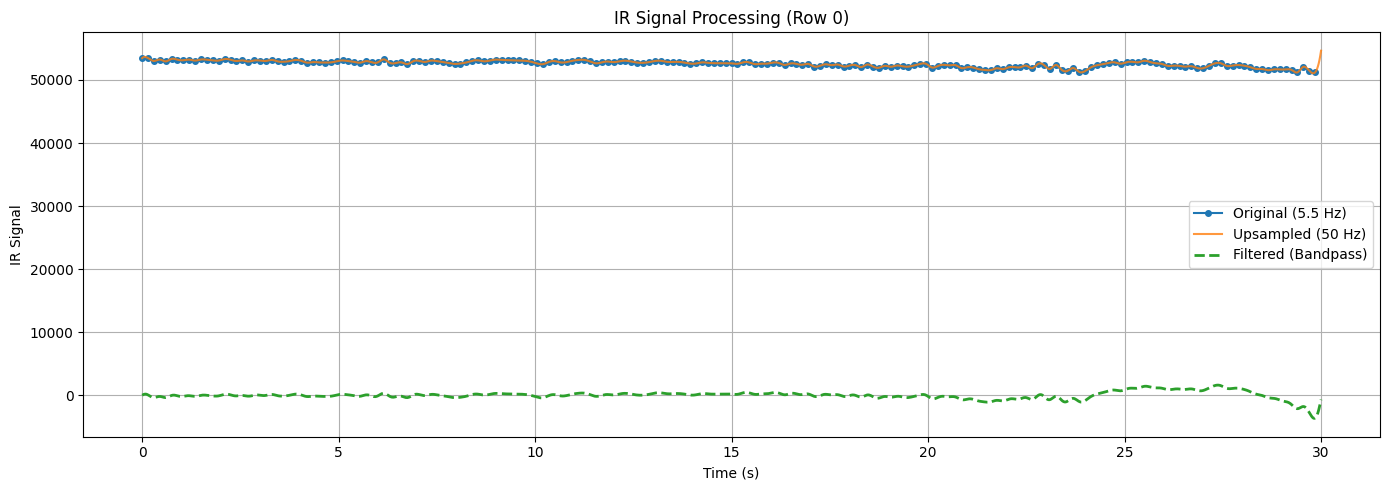

In [97]:
import matplotlib.pyplot as plt

# Choose a row to visualize (e.g., first subject)
row_index = 0

# Original time scale
t_orig_plot = np.arange(ir_data.shape[1]) / fs_original

# Upsampled time scale
t_up_plot = t_upsampled

# Plot
plt.figure(figsize=(14, 5))

plt.plot(t_orig_plot, ir_data[row_index], 'o-', label='Original (5.5 Hz)', markersize=4)
plt.plot(t_up_plot, ir_upsampled[row_index], '-', label='Upsampled (50 Hz)', alpha=0.8)
plt.plot(t_up_plot, ir_filtered[row_index], '--', label='Filtered (Bandpass)', linewidth=2)

plt.title(f'IR Signal Processing (Row {row_index})')
plt.xlabel('Time (s)')
plt.ylabel('IR Signal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


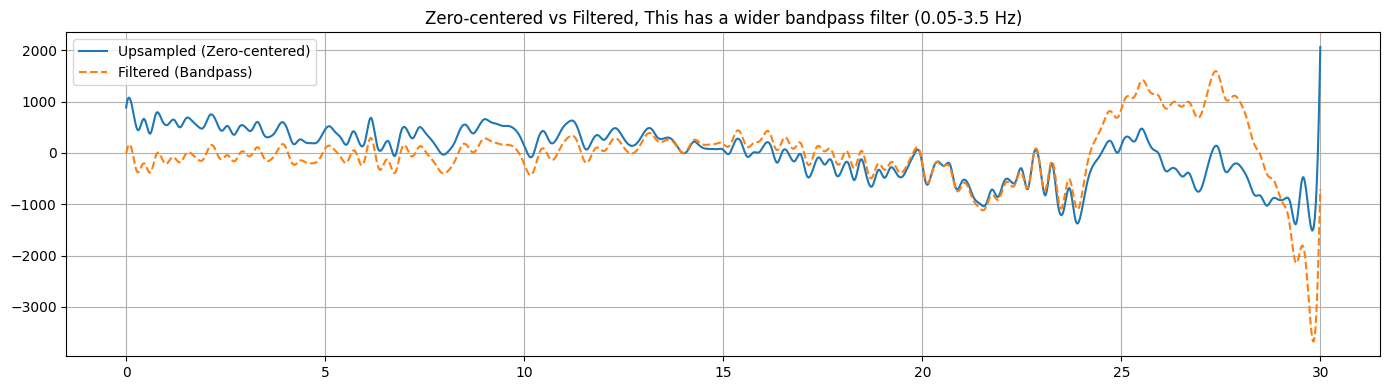

In [98]:
plt.figure(figsize=(14, 4))
plt.plot(t_up_plot, ir_upsampled[row_index] - np.mean(ir_upsampled[row_index]), label='Upsampled (Zero-centered)')
plt.plot(t_up_plot, ir_filtered[row_index], label='Filtered (Bandpass)', linestyle='--')
plt.title("Zero-centered vs Filtered, This has a wider bandpass filter (0.05-3.5 Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


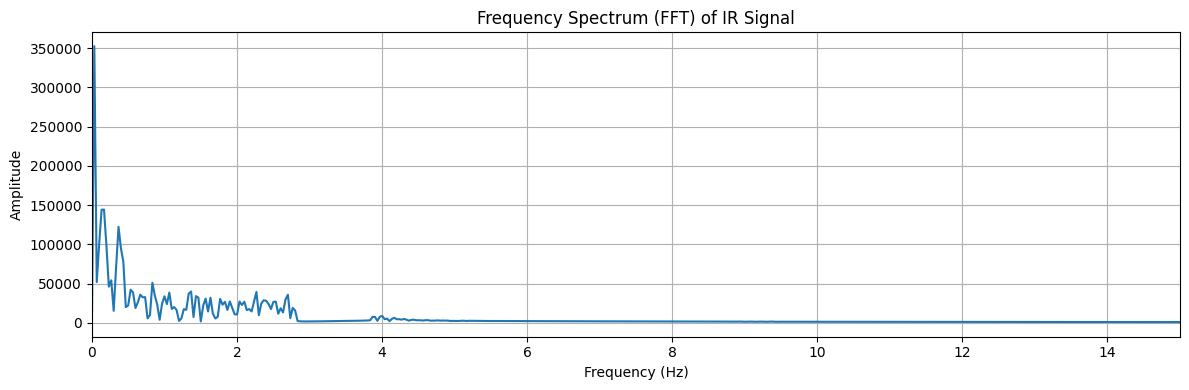

In [99]:
from scipy.fft import fft, fftfreq

# Choose a row
row_index = 0
signal = ir_upsampled[row_index] - np.mean(ir_upsampled[row_index])  # zero-mean

# Sampling frequency (after upsampling)
fs = fs_target
n = len(signal)
yf = fft(signal)
xf = fftfreq(n, 1 / fs)

# Keep only the positive frequencies
xf = xf[:n//2]
yf = np.abs(yf[:n//2])

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(xf, yf)
plt.title("Frequency Spectrum (FFT) of IR Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 15)  # zoom to relevant range
plt.show()


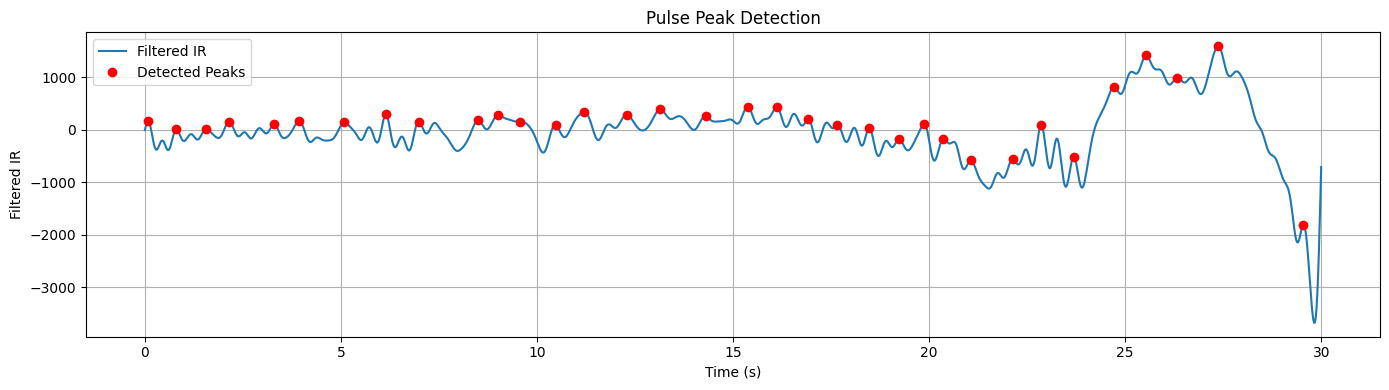

In [100]:
from scipy.signal import find_peaks

# Use the filtered row
signal = ir_filtered[row_index]

# Detect peaks
peaks, _ = find_peaks(signal, distance=fs_target * 0.5)  # min 0.5 sec between peaks

# Plot
plt.figure(figsize=(14, 4))
plt.plot(t_up_plot, signal, label='Filtered IR')
plt.plot(t_up_plot[peaks], signal[peaks], 'ro', label='Detected Peaks')
plt.title('Pulse Peak Detection')
plt.xlabel('Time (s)')
plt.ylabel('Filtered IR')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [103]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis, entropy
from scipy.integrate import simpson


In [104]:
def detect_peaks(signal, fs):
    distance = int(0.4 * fs)  # ~150 bpm max
    peaks, _ = find_peaks(signal, distance=distance, prominence=100)
    return peaks

def detect_feet(signal, peaks):
    feet = []
    for i in range(1, len(peaks)):
        prev = peaks[i - 1]
        curr = peaks[i]
        foot = np.argmin(signal[prev:curr]) + prev
        feet.append(foot)
    return np.array(feet)


In [105]:
def extract_morph_features(signal, feet, peaks, fs):
    beats = []
    for i in range(1, len(feet)):
        start = feet[i - 1]
        end = feet[i]
        peak_candidates = peaks[(peaks > start) & (peaks < end)]
        if len(peak_candidates) != 1:
            continue  # skip noisy or ambiguous beats

        peak = peak_candidates[0]
        amp = signal[peak] - signal[start]
        width = (end - start) / fs
        rise_time = (peak - start) / fs
        slope = amp / rise_time if rise_time > 0 else 0
        auc = simpson(signal[start:end], dx=1/fs)

        beats.append({
            'amplitude': amp,
            'width': width,
            'rise_time': rise_time,
            'slope': slope,
            'auc': auc,
        })

    return pd.DataFrame(beats)


In [106]:
def extract_entropy_features(signal):
    signal = signal - np.mean(signal)
    hist, _ = np.histogram(signal, bins=20, density=True)
    shannon = entropy(hist + 1e-12)  # small epsilon to avoid log(0)
    return {
        "shannon_entropy": shannon,
        "signal_skew": skew(signal),
        "signal_kurtosis": kurtosis(signal),
    }


In [107]:
def process_signal_row(signal, fs):
    peaks = detect_peaks(signal, fs)
    feet = detect_feet(signal, peaks)

    morph_df = extract_morph_features(signal, feet, peaks, fs)
    if morph_df.empty:
        return None  # skip bad signal

    agg = morph_df.agg(['mean', 'std', 'min', 'max']).to_dict()
    flat = {f"{k}_{stat}": v for k, d in agg.items() for stat, v in d.items()}

    entropy_feats = extract_entropy_features(signal)

    return {**flat, **entropy_feats}


In [108]:
fs = fs_target  # usually 50
feature_rows = []

for i, row in enumerate(ir_filtered):
    features = process_signal_row(row, fs)
    if features is not None:
        features["row_index"] = i  # optional
        feature_rows.append(features)

feature_df = pd.DataFrame(feature_rows)
feature_df.head()


,amplitude_mean,amplitude_std,amplitude_min,amplitude_max,width_mean,width_std,width_min,width_max,rise_time_mean,rise_time_std,...,slope_min,slope_max,auc_mean,auc_std,auc_min,auc_max,shannon_entropy,signal_skew,signal_kurtosis,row_index
0,459.244085,337.471006,134.920565,1917.563512,0.845882,0.421815,0.34,2.46,0.399412,0.254248,...,405.479379,3129.947100,27.117051,366.316921,-907.517589,1356.990294,2.015196,-1.252478,6.610874,0
1,374.652518,449.375599,102.837260,2154.442079,1.116000,0.609766,0.66,2.90,0.714000,0.495542,...,61.109512,1404.984999,-8.031046,121.038168,-346.388463,232.736847,1.607457,-3.392556,18.774345,1
2,252.088102,104.820125,123.512095,622.349545,0.724865,0.247808,0.48,1.26,0.370811,0.200144,...,229.270681,1622.732343,17.356257,188.516498,-278.197148,571.662791,1.971791,-1.773336,9.636284,2
3,161.803701,68.292222,105.450524,352.030398,1.948333,2.376972,0.86,8.96,0.975000,0.912105,...,98.802401,289.038063,-12.428629,64.578530,-127.827364,94.715599,1.961767,1.559637,8.750977,3
4,292.630073,259.634224,105.968105,1046.600984,1.506667,0.965155,0.52,3.52,0.797333,0.794620,...,143.386758,1628.782667,-76.651640,224.946248,-569.864735,307.221806,2.059693,-1.834367,8.887005,4


In [109]:
# Check for null values in df_final
null_counts = feature_df.isnull().sum()
print(null_counts[null_counts > 0])

amplitude_std    4
width_std        4
rise_time_std    4
slope_std        4
auc_std          4
dtype: int64


In [74]:
feature_df.to_csv("ppg_features_extracted1.csv", index=False)
print("✅ Saved to ppg_features_extracted.csv")


✅ Saved to ppg_features_extracted.csv


In [75]:
import numpy as np
import pandas as pd

from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis, entropy
from scipy.integrate import simpson  # SciPy >= 1.14


In [76]:
def detect_systolic_peaks(signal, fs, min_bpm=35, max_bpm=200, prom_percentile=70):
    """
    Detect systolic peaks with reasonable HR constraints and adaptive prominence.
    """
    # Convert bpm limits to samples
    min_dist = int((60.0 / max_bpm) * fs)  # minimum distance between peaks
    # Adaptive prominence based on signal spread
    prom = np.percentile(signal - np.min(signal), prom_percentile) * 0.15
    prom = max(prom, 1e-6)  # avoid 0

    peaks, props = find_peaks(signal, distance=min_dist, prominence=prom)
    return peaks, props

def detect_feet(signal, peaks):
    """
    Detect pulse onsets (feet) as the local minima between consecutive peaks.
    Returns feet aligned to beats: foot[i] is onset before peak[i] (for i>=1).
    """
    if len(peaks) < 2:
        return np.array([], dtype=int)

    feet = []
    # For each interval between peaks, take the minimum
    for i in range(1, len(peaks)):
        seg_start = peaks[i-1]
        seg_end   = peaks[i]
        if seg_end - seg_start < 2:
            continue
        local_min = np.argmin(signal[seg_start:seg_end]) + seg_start
        feet.append(local_min)
    return np.array(feet, dtype=int)


In [77]:
def extract_morph_features(signal, fs, peaks, feet):
    """
    Build per-beat features using segments [foot(i) -> peak(i+1) -> foot(i+1)].
    We align beats so each beat has a unique peak within foot..next_foot.
    """
    if len(feet) < 2 or len(peaks) < 2:
        return pd.DataFrame([])

    beats = []
    # feet are between peaks: feet[k] lies in (peaks[k], peaks[k+1])
    # Use consecutive feet to define a beat window
    for k in range(0, len(feet)-1):
        start = feet[k]
        end   = feet[k+1]
        if end <= start + 2:
            continue

        # Find the (single) peak inside this beat window
        pk_candidates = peaks[(peaks > start) & (peaks < end)]
        if len(pk_candidates) != 1:
            # ambiguous beat, skip
            continue
        pk = pk_candidates[0]

        foot_val = signal[start]
        peak_val = signal[pk]
        end_val  = signal[end]

        amp = peak_val - foot_val
        width_sec = (end - start) / fs
        rise_time_sec = (pk - start) / fs
        slope_up = amp / rise_time_sec if rise_time_sec > 0 else np.nan
        auc = simpson(signal[start:end], dx=1/fs)

        # Descending limb features (optional)
        fall_time_sec = (end - pk) / fs
        fall_amp = peak_val - end_val
        slope_down = fall_amp / fall_time_sec if fall_time_sec > 0 else np.nan

        beats.append({
            "amplitude": amp,
            "width_sec": width_sec,
            "rise_time_sec": rise_time_sec,
            "slope_up": slope_up,
            "auc": auc,
            "fall_time_sec": fall_time_sec,
            "slope_down": slope_down,
        })

    return pd.DataFrame(beats)


In [78]:
def sdppg_features(signal, fs, peaks, feet):
    if len(feet) < 2:
        return {}

    d1 = np.gradient(signal) * fs
    d2 = np.gradient(d1) * fs

    ratios = {"b_over_a": [], "c_over_a": [], "d_over_a": [], "e_over_a": []}
    ai_list = []

    for k in range(len(feet)-1):
        start, end = feet[k], feet[k+1]
        if end - start < 5:
            continue
        if end > len(signal):  # ✅ guard
            continue

        seg = signal[start:end]
        sd2 = d2[start:end]

        # --- your detection logic here ---

        # Augmentation Index proxy (safer indexing)
        if len(seg) > 5:
            pk_rel = np.argmax(seg)
            if pk_rel+2 < len(seg)-2:
                after = seg[pk_rel+1:]
                if len(after) > 4:
                    sh_rel = np.argmax(after) + pk_rel + 1
                    if sh_rel < len(seg):
                        P1 = seg[pk_rel]
                        P2 = seg[sh_rel]
                        if P1 != 0:
                            ai_list.append((P2 - seg[0]) / (P1 - seg[0]))

    out = {f"sdppg_{k}_mean": (np.nan if len(v)==0 else float(np.mean(v)))
           for k, v in ratios.items()}
    out.update({f"sdppg_{k}_std": (np.nan if len(v)==0 else float(np.std(v, ddof=1)))
                for k, v in ratios.items()})
    out["ai_proxy_mean"] = (np.nan if len(ai_list)==0 else float(np.mean(ai_list)))
    out["ai_proxy_std"]  = (np.nan if len(ai_list)==0 else float(np.std(ai_list, ddof=1)))
    return out


In [79]:
def hrv_from_peaks(peaks, fs):
    """
    Compute heart-rate and time-domain HRV from systolic peak intervals.
    """
    if len(peaks) < 3:
        return {
            "bpm_mean": np.nan, "bpm_std": np.nan,
            "ibi_mean": np.nan, "ibi_std": np.nan,
            "sdnn": np.nan, "rmssd": np.nan,
            "num_beats": len(peaks)
        }

    # Inter-beat intervals (seconds)
    ibi = np.diff(peaks) / fs
    bpm = 60.0 / ibi

    sdnn = np.std(ibi, ddof=1)
    rmssd = np.sqrt(np.mean(np.diff(ibi)**2))

    return {
        "bpm_mean": float(np.mean(bpm)),
        "bpm_std": float(np.std(bpm, ddof=1)) if len(bpm)>1 else 0.0,
        "ibi_mean": float(np.mean(ibi)),
        "ibi_std": float(np.std(ibi, ddof=1)) if len(ibi)>1 else 0.0,
        "sdnn": float(sdnn),
        "rmssd": float(rmssd),
        "num_beats": int(len(peaks))
    }


In [80]:
def shannon_entropy(signal, bins=30):
    s = signal - np.mean(signal)
    hist, _ = np.histogram(s, bins=bins, density=True)
    return float(entropy(hist + 1e-12))  # avoid log(0)

def poincare_sd1_sd2_from_peaks(peaks, fs):
    """
    Poincaré features from successive IBIs.
    """
    if len(peaks) < 3:
        return {"sd1": np.nan, "sd2": np.nan}

    ibi = np.diff(peaks) / fs
    x1, x2 = ibi[:-1], ibi[1:]
    diff = x2 - x1
    sd1 = np.sqrt(np.var(diff) / 2.0)
    mean_ibi = np.mean(ibi)
    sd2 = np.sqrt(2*np.var(ibi) - (np.var(diff)/2.0))
    return {"sd1": float(sd1), "sd2": float(sd2)}


In [81]:
def aggregate_beats(df):
    """
    df: per-beat DataFrame with columns:
        amplitude, width_sec, rise_time_sec, slope_up, auc, fall_time_sec, slope_down
    Returns dict of mean/std/min/max for each.
    """
    if df.empty:
        return {}

    agg = df.agg(['mean', 'std', 'min', 'max']).to_dict()
    flat = {f"{k}_{stat}": float(v) for k, d in agg.items() for stat, v in d.items()}
    return flat

def features_for_row(signal, fs):
    # Detect peaks & feet
    peaks, _ = detect_systolic_peaks(signal, fs)
    feet = detect_feet(signal, peaks)

    # Morphology
    beat_df = extract_morph_features(signal, fs, peaks, feet)
    morph = aggregate_beats(beat_df)

    # HR/HRV
    hrv = hrv_from_peaks(peaks, fs)
    poinc = poincare_sd1_sd2_from_peaks(peaks, fs)

    # SDPPG / AI proxy
    sdppg = sdppg_features(signal, fs, peaks, feet)

    # Nonlinear (signal-level)
    nonlin = {
        "shannon_entropy": shannon_entropy(signal),
        "signal_skew": float(skew(signal - np.mean(signal))),
        "signal_kurtosis": float(kurtosis(signal - np.mean(signal))),
    }

    # Useful counts
    counts = {
        "n_valid_beats": 0 if beat_df is None or beat_df.empty else int(len(beat_df)),
        "n_peaks": int(len(peaks)),
        "n_feet": int(len(feet)),
    }

    out = {}
    out.update(morph)
    out.update(hrv)
    out.update(poinc)
    out.update(sdppg)
    out.update(nonlin)
    out.update(counts)
    return out


In [82]:
# Assumptions: 
#   ir_filtered: np.ndarray shape (n_rows, n_samples) — filtered, upsampled signals
#   fs_target: sampling rate (e.g., 50)

fs = fs_target
rows = []
for i, sig in enumerate(ir_filtered):
    if sig is None or np.all(~np.isfinite(sig)):
        continue
    feats = features_for_row(sig.astype(float), fs)
    feats["row_index"] = i  # keep mapping to original dataset row (optional)
    rows.append(feats)

feature_df = pd.DataFrame(rows)

# (Optional) join BP labels or metadata if you have original df with BP columns:
# feature_df = feature_df.merge(df[['systolic_BP','diastolic_BP']].reset_index().rename(columns={'index':'row_index'}),
#                               on='row_index', how='left')

feature_df.head()


c:\Users\Ridwan Sharif\Documents\University_space\Defence\models\venv\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Ridwan Sharif\Documents\University_space\Defence\models\venv\Lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Ridwan Sharif\Documents\University_space\Defence\models\venv\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Ridwan Sharif\Documents\University_space\Defence\models\venv\Lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Ridwan Sharif\Documents\University_space\Defence\models\venv\Lib\site-packages\numpy\_core\_methods.py:223: Run

,amplitude_mean,amplitude_std,amplitude_min,amplitude_max,width_sec_mean,width_sec_std,width_sec_min,width_sec_max,rise_time_sec_mean,rise_time_sec_std,...,sdppg_e_over_a_std,ai_proxy_mean,ai_proxy_std,shannon_entropy,signal_skew,signal_kurtosis,n_valid_beats,n_peaks,n_feet,row_index
0,1178.101046,784.069015,608.670010,2518.503653,3.788000,2.678753,2.18,8.54,2.076,1.771914,...,NaN,0.995903,0.004581,2.410949,-1.252478,6.610874,5,7,6,0
1,908.975039,700.543470,533.707039,2154.442079,1.684000,0.913061,0.80,2.90,1.256,0.691289,...,NaN,0.991837,0.009991,1.917966,-3.392556,18.774345,5,7,6,1
2,866.659943,NaN,866.659943,866.659943,15.040000,NaN,15.04,15.04,6.280,NaN,...,NaN,0.997661,NaN,2.337882,-1.773336,9.636284,1,3,2,2
3,156.561056,68.062358,93.649314,352.030398,1.798462,2.093601,0.80,8.16,0.940,0.882345,...,NaN,0.990461,0.007843,2.326915,1.559637,8.750977,13,15,14,3
4,610.707618,63.038396,566.132741,655.282496,9.080000,8.994398,2.72,15.44,6.550,8.527708,...,NaN,0.994730,0.005409,2.437624,-1.834367,8.887005,2,4,3,4


In [83]:
# Check for null values in df_final
null_counts = feature_df.isnull().sum()
print(null_counts[null_counts > 0])

amplitude_mean          48
amplitude_std           68
amplitude_min           48
amplitude_max           48
width_sec_mean          48
width_sec_std           68
width_sec_min           48
width_sec_max           48
rise_time_sec_mean      48
rise_time_sec_std       68
rise_time_sec_min       48
rise_time_sec_max       48
slope_up_mean           48
slope_up_std            68
slope_up_min            48
slope_up_max            48
auc_mean                48
auc_std                 68
auc_min                 48
auc_max                 48
fall_time_sec_mean      48
fall_time_sec_std       68
fall_time_sec_min       48
fall_time_sec_max       48
slope_down_mean         48
slope_down_std          68
slope_down_min          48
slope_down_max          48
bpm_mean                48
bpm_std                 48
ibi_mean                48
ibi_std                 48
sdnn                    48
rmssd                   48
sd1                     48
sd2                     54
sdppg_b_over_a_mean    317
s

In [ ]:
feature_df.to_csv("ppg_feature_dataset2.csv", index=False)


In [125]:
print(feature_df.columns.tolist())
print(feature_df.shape)

['amplitude_mean', 'amplitude_std', 'amplitude_min', 'amplitude_max', 'width_sec_mean', 'width_sec_std', 'width_sec_min', 'width_sec_max', 'rise_time_sec_mean', 'rise_time_sec_std', 'rise_time_sec_min', 'rise_time_sec_max', 'slope_up_mean', 'slope_up_std', 'slope_up_min', 'slope_up_max', 'auc_mean', 'auc_std', 'auc_min', 'auc_max', 'fall_time_sec_mean', 'fall_time_sec_std', 'fall_time_sec_min', 'fall_time_sec_max', 'slope_down_mean', 'slope_down_std', 'slope_down_min', 'slope_down_max', 'bpm_mean', 'bpm_std', 'ibi_mean', 'ibi_std', 'sdnn', 'rmssd', 'num_beats', 'sd1', 'sd2', 'sdppg_b_over_a_mean', 'sdppg_c_over_a_mean', 'sdppg_d_over_a_mean', 'sdppg_e_over_a_mean', 'sdppg_b_over_a_std', 'sdppg_c_over_a_std', 'sdppg_d_over_a_std', 'sdppg_e_over_a_std', 'ai_proxy_mean', 'ai_proxy_std', 'shannon_entropy', 'signal_skew', 'signal_kurtosis', 'n_valid_beats', 'n_peaks', 'n_feet', 'row_index']
(317, 54)


In [128]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, welch
from scipy.stats import skew, kurtosis, entropy as shannon_entropy_scipy
from scipy.integrate import simpson


In [137]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

def sample_entropy(x, m=2, r=None):
    """
    Vectorized Sample Entropy (SampEn).
    Uses Chebyshev (max-abs) distance; excludes self-matches.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    N = x.size
    if r is None:
        std = np.std(x)
        r = 0.2 * std if std > 0 else 1e-12
    if N <= (m + 1):
        return np.nan

    Xm  = sliding_window_view(x, m)      # shape (N-m+1, m)
    Xm1 = sliding_window_view(x, m + 1)  # shape (N-m,   m+1)

    def _count_matches(X):
        # Pairwise Chebyshev distances between all windows
        D = np.max(np.abs(X[:, None, :] - X[None, :, :]), axis=2)
        # Exclude self-matches by setting diagonal to +inf
        if D.shape[0] == D.shape[1]:
            np.fill_diagonal(D, np.inf)
        return np.sum(D <= r)

    B = _count_matches(Xm)
    A = _count_matches(Xm1)
    if B == 0 or A == 0:
        return np.nan
    return -np.log(A / B)

def approximate_entropy(x, m=2, r=None):
    """
    Vectorized Approximate Entropy (ApEn) per Pincus 1991 (biased).
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    N = x.size
    if r is None:
        std = np.std(x)
        r = 0.2 * std if std > 0 else 1e-12
    if N <= (m + 1):
        return np.nan

    Xm  = sliding_window_view(x, m)      # (N-m+1, m)
    Xm1 = sliding_window_view(x, m + 1)  # (N-m,   m+1)

    def _phi(X):
        # Chebyshev distances for all pairs
        D = np.max(np.abs(X[:, None, :] - X[None, :, :]), axis=2)
        C = np.mean(D <= r, axis=1)
        C[C == 0] = 1e-12  # avoid log(0)
        return np.mean(np.log(C))

    return _phi(Xm) - _phi(Xm1)


In [138]:


def hjorth_params(x):
    """
    Hjorth activity, mobility, complexity.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    var0 = np.var(x)
    if var0 == 0:
        return np.nan, np.nan, np.nan
    dx = np.diff(x)
    var1 = np.var(dx)
    ddx = np.diff(dx)
    var2 = np.var(ddx)

    activity = var0
    mobility = np.sqrt(var1 / var0) if var0 > 0 else np.nan
    complexity = np.sqrt((var2 / var1)) / mobility if (var1 > 0 and mobility > 0) else np.nan
    return float(activity), float(mobility), float(complexity)

def detrended_fluctuation_analysis(x, min_window=4, max_window=None, n_windows=10):
    """
    Simple DFA alpha estimate.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    y = np.cumsum(x)
    N = len(y)
    if max_window is None:
        max_window = N // 4
    if max_window <= min_window or N < 16:
        return np.nan

    scales = np.unique(np.logspace(np.log10(min_window), np.log10(max_window), n_windows).astype(int))
    F = []
    for s in scales:
        if s < 2: 
            continue
        n_segments = N // s
        if n_segments < 2:
            continue
        rms = []
        for v in range(n_segments):
            seg = y[v*s:(v+1)*s]
            t = np.arange(s)
            # linear detrend
            p = np.polyfit(t, seg, 1)
            trend = np.polyval(p, t)
            rms.append(np.sqrt(np.mean((seg - trend)**2)))
        if len(rms) > 0:
            F.append((s, np.mean(rms)))
    if len(F) < 2:
        return np.nan
    scales_log = np.log([f[0] for f in F])
    F_log = np.log([f[1] for f in F])
    alpha = np.polyfit(scales_log, F_log, 1)[0]
    return float(alpha)

def petrosian_fd(x):
    """
    Petrosian Fractal Dimension.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    N = len(x)
    if N < 2:
        return np.nan
    diff_sign = np.sign(np.diff(x))
    N_delta = np.sum(diff_sign[1:] != diff_sign[:-1])
    if N <= 0 or N_delta <= 0:
        return np.nan
    return float(np.log10(N) / (np.log10(N) + np.log10(N / (N + 0.4 * N_delta))))


In [130]:
def spectral_features(x, fs, lf_band=(0.04, 0.15), hf_band=(0.15, 0.40), nperseg=None):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    if nperseg is None:
        nperseg = min(len(x), 256)
    if len(x) < 8:
        return dict.fromkeys([
            "spec_centroid_hz", "spec_entropy", "lf_energy", "hf_energy", "total_power"
        ], np.nan)

    f, Pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg//2, scaling='density')
    Pxx = np.maximum(Pxx, 1e-20)  # avoid zeros

    total_power = np.trapz(Pxx, f)
    # spectral centroid (power-weighted mean frequency)
    spec_centroid = np.trapz(f * Pxx, f) / total_power if total_power > 0 else np.nan

    # spectral entropy (Shannon) over normalized spectrum
    Pn = Pxx / np.sum(Pxx)
    spec_ent = shannon_entropy_scipy(Pn)

    # band energies
    def band_energy(band):
        mask = (f >= band[0]) & (f < band[1])
        if not np.any(mask):
            return 0.0
        return float(np.trapz(Pxx[mask], f[mask]))

    lf_energy = band_energy(lf_band)
    hf_energy = band_energy(hf_band)

    return {
        "spec_centroid_hz": float(spec_centroid),
        "spec_entropy": float(spec_ent),
        "lf_energy": lf_energy,
        "hf_energy": hf_energy,
        "total_power": float(total_power),
    }


In [131]:
def width_at_percent(signal, start, peak, end, fs, percent=0.25):
    """
    Width at percent of amplitude between foot (start) and peak within the beat window.
    Finds up-crossing on rise and down-crossing on fall relative to foot level.
    Returns width in seconds (or np.nan if not found).
    """
    foot_val = signal[start]
    peak_val = signal[peak]
    target = foot_val + percent * (peak_val - foot_val)

    # rising limb: from start -> peak
    up_seg = signal[start:peak+1]
    up_idx = np.where(up_seg >= target)[0]
    if len(up_idx) == 0:
        return np.nan
    up_cross = start + up_idx[0]

    # falling limb: from peak -> end
    down_seg = signal[peak:end]
    down_idx = np.where(down_seg <= target)[0]
    if len(down_idx) == 0:
        return np.nan
    down_cross = peak + down_idx[0]

    return (down_cross - up_cross) / fs

def dicrotic_notch(signal, peak, end):
    """
    Find dicrotic notch as first local minimum after peak before beat end.
    Returns (notch_index, notch_amp_relative_to_foot), or (None, np.nan).
    """
    if end - peak < 3:
        return None, np.nan
    seg = signal[peak+1:end]
    if len(seg) < 3:
        return None, np.nan

    # local minima: invert segment and find peaks
    inv = -seg
    mins, _ = find_peaks(inv, distance=2)
    if len(mins) == 0:
        return None, np.nan
    notch_rel = mins[0] + (peak + 1)
    return notch_rel, float(signal[notch_rel])


In [132]:
def extract_morph_features_enhanced(signal, fs, peaks, feet):
    """
    Per-beat features:
      amplitude, width_sec, rise_time_sec, slope_up, auc,
      fall_time_sec, slope_down,
      rise_fall_ratio,
      width25, width75,
      dicrotic_notch_amp_rel (vs foot), dicrotic_notch_time_from_peak
    """
    if len(feet) < 2 or len(peaks) < 2:
        return pd.DataFrame([])

    rows = []
    for k in range(0, len(feet)-1):
        start, end = feet[k], feet[k+1]
        if end <= start + 3:
            continue

        pk_candidates = peaks[(peaks > start) & (peaks < end)]
        if len(pk_candidates) != 1:
            continue
        pk = pk_candidates[0]

        foot_val = signal[start]
        peak_val = signal[pk]
        end_val  = signal[end]

        amp = peak_val - foot_val
        width_sec = (end - start) / fs
        rise_time_sec = (pk - start) / fs
        slope_up = amp / rise_time_sec if rise_time_sec > 0 else np.nan
        auc = simpson(signal[start:end], dx=1/fs)

        fall_time_sec = (end - pk) / fs
        fall_amp = peak_val - end_val
        slope_down = fall_amp / fall_time_sec if fall_time_sec > 0 else np.nan
        rise_fall_ratio = (rise_time_sec / fall_time_sec) if (fall_time_sec and fall_time_sec > 0) else np.nan

        w25 = width_at_percent(signal, start, pk, end, fs, percent=0.25)
        w75 = width_at_percent(signal, start, pk, end, fs, percent=0.75)

        notch_idx, notch_val = dicrotic_notch(signal, pk, end)
        if notch_idx is not None:
            notch_amp_rel_foot = notch_val - foot_val
            notch_time_from_peak = (notch_idx - pk) / fs
        else:
            notch_amp_rel_foot = np.nan
            notch_time_from_peak = np.nan

        rows.append({
            "amplitude": amp,
            "width_sec": width_sec,
            "rise_time_sec": rise_time_sec,
            "slope_up": slope_up,
            "auc": auc,
            "fall_time_sec": fall_time_sec,
            "slope_down": slope_down,
            "rise_fall_ratio": rise_fall_ratio,
            "width25_sec": w25,
            "width75_sec": w75,
            "notch_amp_rel_foot": notch_amp_rel_foot,
            "notch_time_from_peak": notch_time_from_peak,
            "valid": int(np.isfinite(amp) and np.isfinite(width_sec) and np.isfinite(rise_time_sec))
        })

    return pd.DataFrame(rows)


In [133]:
def snr_physio_band(signal, fs, band=(0.05, 3.5)):
    """
    SNR proxy = power in physiological band / power outside (Welch PSD).
    """
    signal = np.asarray(signal, dtype=float) - np.mean(signal)
    if len(signal) < 8:
        return np.nan
    f, Pxx = welch(signal, fs=fs, nperseg=min(len(signal), 256), noverlap=128, scaling='density')
    band_mask = (f >= band[0]) & (f <= band[1])
    in_power = np.trapz(Pxx[band_mask], f[band_mask]) if np.any(band_mask) else 0.0
    out_mask = ~band_mask
    out_power = np.trapz(Pxx[out_mask], f[out_mask]) if np.any(out_mask) else 1e-20
    return float(in_power / out_power)


In [134]:
def hrv_from_peaks(peaks, fs):
    if len(peaks) < 3:
        return {"bpm_mean": np.nan, "bpm_std": np.nan, "ibi_mean": np.nan,
                "ibi_std": np.nan, "sdnn": np.nan, "rmssd": np.nan, "num_beats": int(len(peaks))}
    ibi = np.diff(peaks) / fs
    bpm = 60.0 / ibi
    sdnn = np.std(ibi, ddof=1)
    rmssd = np.sqrt(np.mean(np.diff(ibi)**2))
    return {
        "bpm_mean": float(np.mean(bpm)),
        "bpm_std": float(np.std(bpm, ddof=1)) if len(bpm) > 1 else 0.0,
        "ibi_mean": float(np.mean(ibi)),
        "ibi_std": float(np.std(ibi, ddof=1)) if len(ibi) > 1 else 0.0,
        "sdnn": float(sdnn),
        "rmssd": float(rmssd),
        "num_beats": int(len(peaks))
    }

def aggregate_beats(df):
    if df is None or df.empty:
        return {}
    agg = df.drop(columns=[c for c in df.columns if c == 'valid']).agg(['mean', 'std', 'min', 'max']).to_dict()
    flat = {f"{k}_{stat}": float(v) for k, d in agg.items() for stat, v in d.items()}
    # quality
    pct_valid = 100.0 * (df['valid'].sum() / len(df)) if 'valid' in df.columns and len(df) else np.nan
    flat['beat_valid_percent'] = float(pct_valid)
    return flat

def features_for_row(signal, fs):
    signal = np.asarray(signal, dtype=float)
    # detect peaks/feet (you already have these functions defined)
    peaks, _ = detect_systolic_peaks(signal, fs)
    feet = detect_feet(signal, peaks)

    # enhanced beat features
    beat_df = extract_morph_features_enhanced(signal, fs, peaks, feet)
    morph = aggregate_beats(beat_df)

    # HR/HRV basics
    hrv = hrv_from_peaks(peaks, fs)

    # nonlinear dynamics
    sampen = sample_entropy(signal)
    apen   = approximate_entropy(signal)
    hj_act, hj_mob, hj_comp = hjorth_params(signal)
    dfa_a  = detrended_fluctuation_analysis(signal)
    pfd    = petrosian_fd(signal)

    # spectral
    spec = spectral_features(signal, fs)

    # quality / SNR
    snr = snr_physio_band(signal, fs)

    # classic stats & entropy (Shannon)
    s0 = signal - np.mean(signal)
    stats = {
        "shannon_entropy": float(shannon_entropy_scipy(np.histogram(s0, bins=30, density=True)[0] + 1e-12)),
        "signal_skew": float(skew(s0)),
        "signal_kurtosis": float(kurtosis(s0)),
        "snr_band": float(snr),
        "sampen": float(sampen) if np.isfinite(sampen) else np.nan,
        "apen": float(apen) if np.isfinite(apen) else np.nan,
        "hjorth_activity": float(hj_act) if np.isfinite(hj_act) else np.nan,
        "hjorth_mobility": float(hj_mob) if np.isfinite(hj_mob) else np.nan,
        "hjorth_complexity": float(hj_comp) if np.isfinite(hj_comp) else np.nan,
        "dfa_alpha": float(dfa_a) if np.isfinite(dfa_a) else np.nan,
        "petrosian_fd": float(pfd) if np.isfinite(pfd) else np.nan,
    }

    out = {}
    out.update(morph)
    out.update(hrv)
    out.update(spec)
    out.update(stats)
    out["n_peaks"] = int(len(peaks))
    out["n_feet"] = int(len(feet))
    out["n_valid_beats"] = 0 if beat_df is None or beat_df.empty else int(len(beat_df))

    return out


In [ ]:
fs = fs_target
rows = []
for i, sig in enumerate(ir_filtered):
    if sig is None or not np.any(np.isfinite(sig)):
        continue
    feats = features_for_row(sig, fs)
    feats["row_index"] = i
    rows.append(feats)

feature_df = pd.DataFrame(rows)
feature_df.to_csv("ppg_feature_dataset_extended.csv", index=False)
feature_df.head()


C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_9072\2842894196.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(Pxx, f)
C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_9072\2842894196.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  spec_centroid = np.trapz(f * Pxx, f) / total_power if total_power > 0 else np.nan
C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_9072\2842894196.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx[mask], f[mask]))
C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_9072\2486489999.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integr

,amplitude_mean,amplitude_std,amplitude_min,amplitude_max,width_sec_mean,width_sec_std,width_sec_min,width_sec_max,rise_time_sec_mean,rise_time_sec_std,...,apen,hjorth_activity,hjorth_mobility,hjorth_complexity,dfa_alpha,petrosian_fd,n_peaks,n_feet,n_valid_beats,row_index
0,1655.525555,948.709071,747.778750,2640.478711,3.326667,0.923544,2.36,4.20,1.840000,0.563205,...,0.110644,683793.372033,0.048364,4.001636,1.507373,1.003312,5,4,3,0
1,914.316188,724.255864,528.496336,2202.658619,2.044000,1.116727,0.94,3.54,1.520000,0.851939,...,0.183051,63643.947701,0.086245,1.972410,1.435343,1.003657,7,6,5,1
2,882.237858,NaN,882.237858,882.237858,16.080000,NaN,16.08,16.08,3.300000,NaN,...,0.080003,331303.841926,0.040335,4.060577,1.523073,1.003110,3,2,1,2
3,172.991227,71.694957,124.669218,358.571976,3.040000,3.395615,1.06,9.88,0.966667,0.725259,...,0.059319,87477.750707,0.033555,4.217725,1.579549,1.002619,11,10,9,3
4,684.874906,18.251657,671.969036,697.780777,10.320000,11.851110,1.94,18.70,5.520000,6.873078,...,0.062909,298614.027689,0.036436,4.074945,1.602709,1.002966,4,3,2,4


In [140]:
print(feature_df.shape)
print(feature_df.columns.tolist())  

(317, 76)
['amplitude_mean', 'amplitude_std', 'amplitude_min', 'amplitude_max', 'width_sec_mean', 'width_sec_std', 'width_sec_min', 'width_sec_max', 'rise_time_sec_mean', 'rise_time_sec_std', 'rise_time_sec_min', 'rise_time_sec_max', 'slope_up_mean', 'slope_up_std', 'slope_up_min', 'slope_up_max', 'auc_mean', 'auc_std', 'auc_min', 'auc_max', 'fall_time_sec_mean', 'fall_time_sec_std', 'fall_time_sec_min', 'fall_time_sec_max', 'slope_down_mean', 'slope_down_std', 'slope_down_min', 'slope_down_max', 'rise_fall_ratio_mean', 'rise_fall_ratio_std', 'rise_fall_ratio_min', 'rise_fall_ratio_max', 'width25_sec_mean', 'width25_sec_std', 'width25_sec_min', 'width25_sec_max', 'width75_sec_mean', 'width75_sec_std', 'width75_sec_min', 'width75_sec_max', 'notch_amp_rel_foot_mean', 'notch_amp_rel_foot_std', 'notch_amp_rel_foot_min', 'notch_amp_rel_foot_max', 'notch_time_from_peak_mean', 'notch_time_from_peak_std', 'notch_time_from_peak_min', 'notch_time_from_peak_max', 'beat_valid_percent', 'bpm_mean',

In [141]:
# If you don't have df in memory anymore, reload it:
# df = pd.read_csv("bp_dataset_resampledV2.csv")

demographic_cols = [c for c in df.columns if not c.startswith('ir_') and not c.startswith('red_')]
demo_df = df[demographic_cols].reset_index().rename(columns={'index':'row_index'})
demo_df.head()


,row_index,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
0,0,100.0,107.0,44,1,180.0,98,30.246914,122,83
1,1,100.0,125.0,30,0,154.0,43,18.131219,102,68
2,2,100.0,93.0,61,0,144.0,62,29.899691,141,93
3,3,98.0,71.0,45,1,172.0,103,34.816117,139,96
4,4,98.0,166.0,23,1,172.0,88,29.745809,112,75


In [142]:
merged_df = feature_df.merge(demo_df, on="row_index", how="left")
print("Merged shape:", merged_df.shape)
merged_df.head()


Merged shape: (317, 85)


,amplitude_mean,amplitude_std,amplitude_min,amplitude_max,width_sec_mean,width_sec_std,width_sec_min,width_sec_max,rise_time_sec_mean,rise_time_sec_std,...,row_index,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
0,1655.525555,948.709071,747.778750,2640.478711,3.326667,0.923544,2.36,4.20,1.840000,0.563205,...,0,100.0,107.0,44,1,180.0,98,30.246914,122,83
1,914.316188,724.255864,528.496336,2202.658619,2.044000,1.116727,0.94,3.54,1.520000,0.851939,...,1,100.0,125.0,30,0,154.0,43,18.131219,102,68
2,882.237858,NaN,882.237858,882.237858,16.080000,NaN,16.08,16.08,3.300000,NaN,...,2,100.0,93.0,61,0,144.0,62,29.899691,141,93
3,172.991227,71.694957,124.669218,358.571976,3.040000,3.395615,1.06,9.88,0.966667,0.725259,...,3,98.0,71.0,45,1,172.0,103,34.816117,139,96
4,684.874906,18.251657,671.969036,697.780777,10.320000,11.851110,1.94,18.70,5.520000,6.873078,...,4,98.0,166.0,23,1,172.0,88,29.745809,112,75


In [143]:
merged_df.to_csv("ppg_features_with_demographics.csv", index=False)
print("✅ Saved: ppg_features_with_demographics.csv")


✅ Saved: ppg_features_with_demographics.csv


In [144]:
print(merged_df.columns.tolist())
print(merged_df.shape)

['amplitude_mean', 'amplitude_std', 'amplitude_min', 'amplitude_max', 'width_sec_mean', 'width_sec_std', 'width_sec_min', 'width_sec_max', 'rise_time_sec_mean', 'rise_time_sec_std', 'rise_time_sec_min', 'rise_time_sec_max', 'slope_up_mean', 'slope_up_std', 'slope_up_min', 'slope_up_max', 'auc_mean', 'auc_std', 'auc_min', 'auc_max', 'fall_time_sec_mean', 'fall_time_sec_std', 'fall_time_sec_min', 'fall_time_sec_max', 'slope_down_mean', 'slope_down_std', 'slope_down_min', 'slope_down_max', 'rise_fall_ratio_mean', 'rise_fall_ratio_std', 'rise_fall_ratio_min', 'rise_fall_ratio_max', 'width25_sec_mean', 'width25_sec_std', 'width25_sec_min', 'width25_sec_max', 'width75_sec_mean', 'width75_sec_std', 'width75_sec_min', 'width75_sec_max', 'notch_amp_rel_foot_mean', 'notch_amp_rel_foot_std', 'notch_amp_rel_foot_min', 'notch_amp_rel_foot_max', 'notch_time_from_peak_mean', 'notch_time_from_peak_std', 'notch_time_from_peak_min', 'notch_time_from_peak_max', 'beat_valid_percent', 'bpm_mean', 'bpm_std'